# IMPORT LIBRARIES

In [1]:
import nbformat
from nbconvert import PythonExporter

with open("data_generator.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

exporter = PythonExporter()
script, _ = exporter.from_notebook_node(nb)

with open("data_generator.py", "w", encoding="utf-8") as f:
    f.write(script)

Saved: instances/demo_clustered_seed4.json
dict_keys(['B', 'K', 'P', 'T', 'D', 'M', 'N', 'a', 'b', 'w', 'dur', 'node', 'base', 'dist', 'tt', 'EF', 'Hkp', 'c_hotel', 'X', 'alpha', 'beta', 'eta', 'gamma', 'c_idle_away', 'delta', '_meta'])


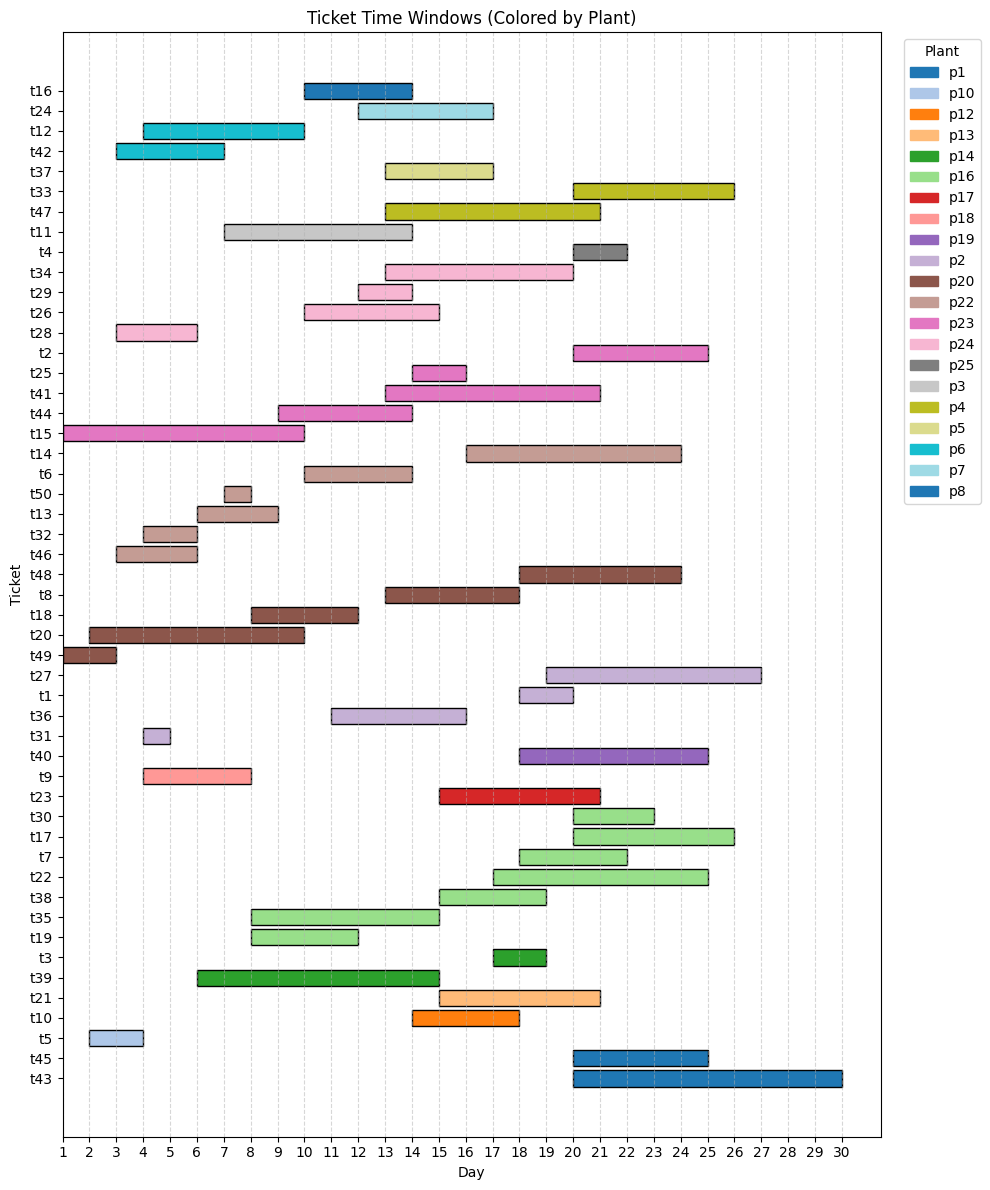

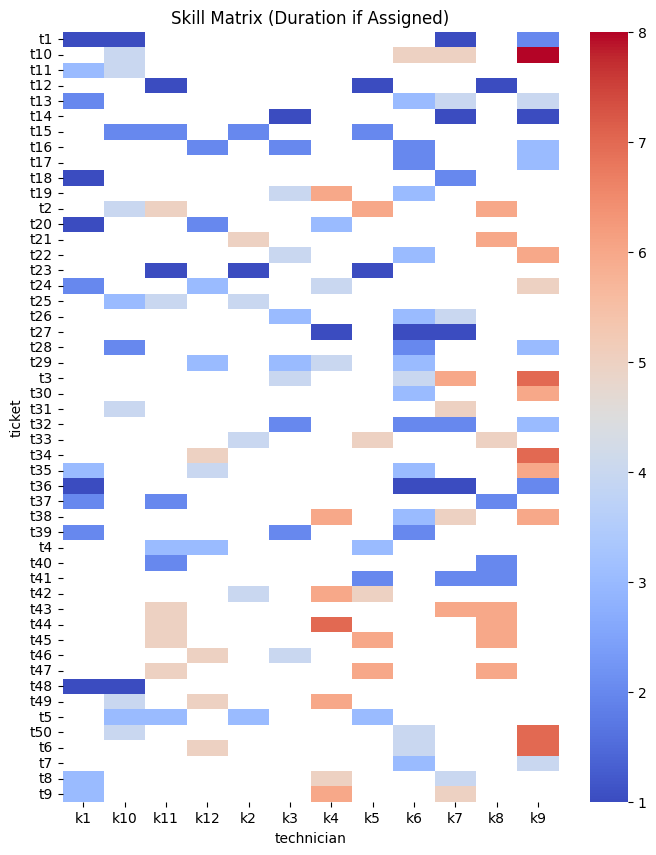

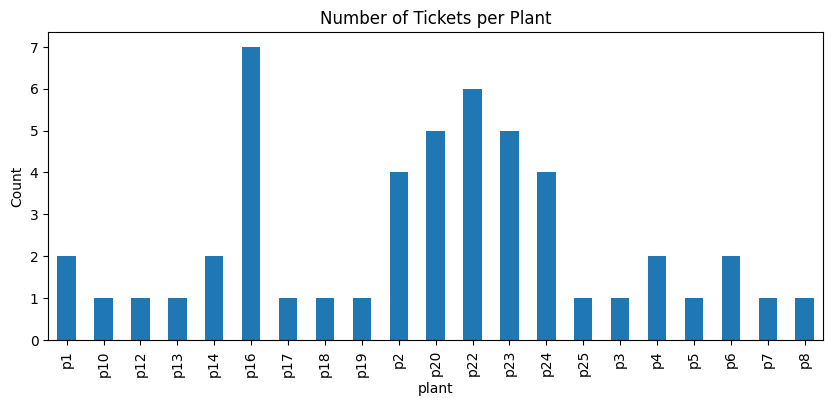

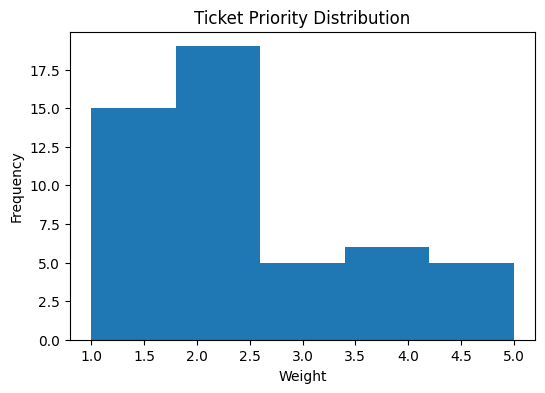

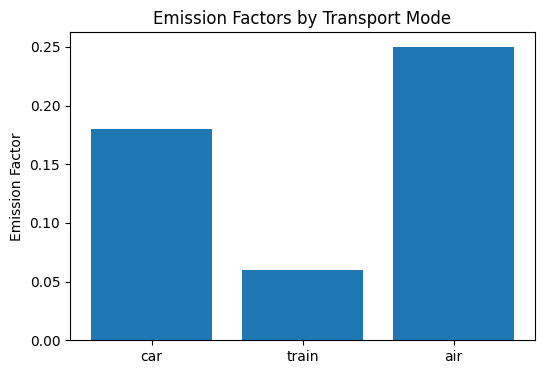

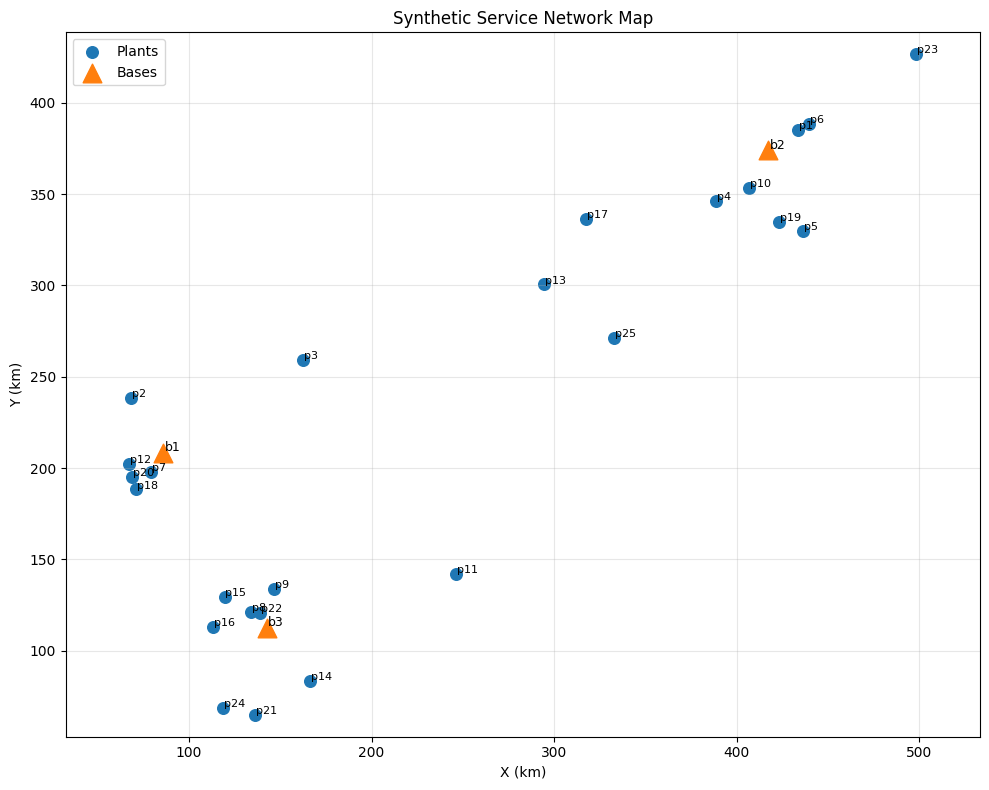

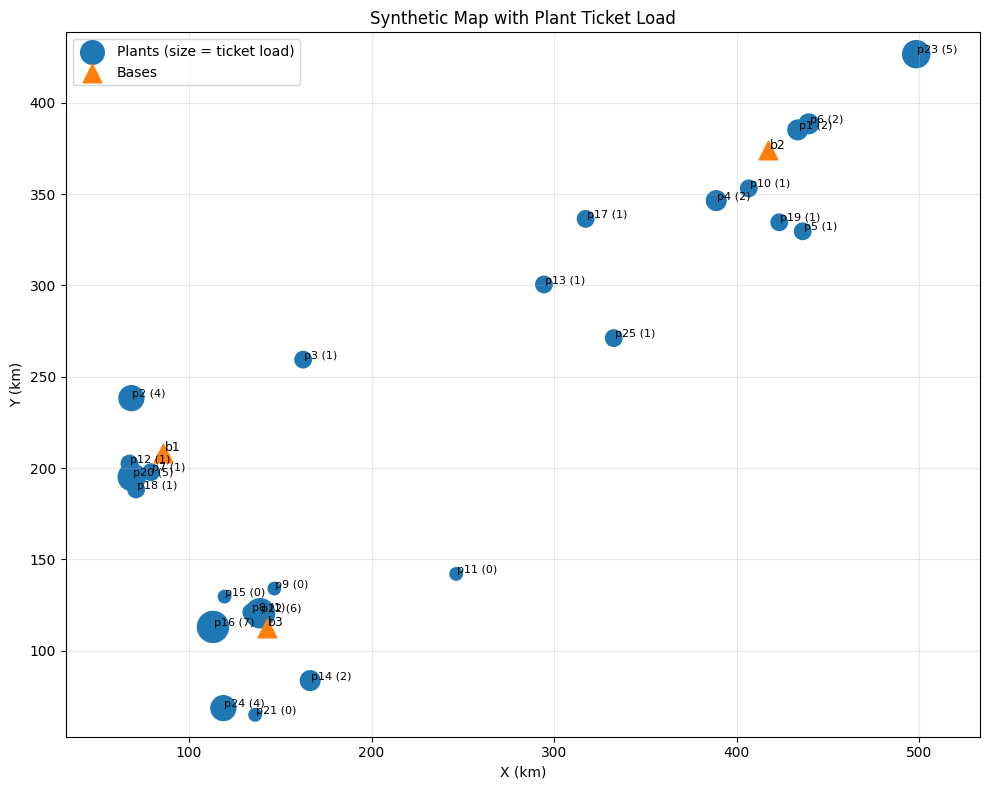

In [2]:
from optimization_model import build_model
import pyomo.environ as pyo
from __future__ import annotations
import json
import os
import copy


from data_generator import generate_instance, save_instance_json


In [3]:
def load_instance_json(path: str) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    tuple_key_fields = {
        "dur": 2,
        "dist": 2,
        "tt": 3,
        "Hkp": 2,
    }

    def decode_keys(d: Dict[str, Any], field_name: str) -> Dict[Any, Any]:
        arity = tuple_key_fields.get(field_name)
        if arity is None:
            return d

        out: Dict[Any, Any] = {}
        for k, v in d.items():
            parts = k.split("|")
            if len(parts) == arity:
                out[tuple(parts)] = v
            else:
                out[k] = v
        return out

    data: Dict[str, Any] = dict(raw)

    for field_name in tuple_key_fields:
        if field_name in data and isinstance(data[field_name], dict):
            data[field_name] = decode_keys(data[field_name], field_name)

    return data

In [4]:
import os
import json
import math
from typing import Any, Dict, Optional

import pyomo.environ as pyo


def _safe_float(value: Any) -> Optional[float]:
    try:
        x = float(value)
        if math.isfinite(x):
            return x
    except Exception:
        pass
    return None


def _index_to_key(index: Any) -> str:
    if isinstance(index, tuple):
        return "|".join(map(str, index))
    return str(index)


def export_results(
    model: pyo.ConcreteModel,
    filepath: str,
    save_zero: bool = False,
    zero_tol: float = 1e-9,
) -> Dict[str, Any]:
    """
    Safely export:
      - objective value
      - all variable values loaded in the Pyomo model

    save_zero = False -> only nonzero values are written
    zero_tol controls what is considered zero

    Returns the exported dictionary.
    Raises RuntimeError only if there is clearly no solution data to export.
    """
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)

    results: Dict[str, Any] = {
        "objective_value": None,
        "variables": {},
        "export_meta": {
            "active_objectives_found": 0,
            "active_variables_found": 0,
            "variables_with_values": 0,
            "stored_variable_entries": 0,
        },
    }

    # ------------------------
    # Objective
    # ------------------------
    active_objectives = list(model.component_data_objects(pyo.Objective, active=True))
    results["export_meta"]["active_objectives_found"] = len(active_objectives)

    if active_objectives:
        obj_val = None
        for obj in active_objectives:
            obj_val = _safe_float(pyo.value(obj, exception=False))
            if obj_val is not None:
                break
        results["objective_value"] = obj_val

    # ------------------------
    # Variables
    # ------------------------
    active_var_blocks = list(model.component_objects(pyo.Var, active=True))
    results["export_meta"]["active_variables_found"] = len(active_var_blocks)

    any_loaded_value = False
    stored_entries = 0
    vars_with_values = 0

    for var in active_var_blocks:
        var_name = var.name
        block_data: Dict[str, float] = {}

        for index in var:
            val = _safe_float(pyo.value(var[index], exception=False))

            if val is None:
                continue

            any_loaded_value = True

            if (not save_zero) and abs(val) < zero_tol:
                continue

            key = _index_to_key(index)
            block_data[key] = val
            stored_entries += 1

        if block_data:
            results["variables"][var_name] = block_data
            vars_with_values += 1

    results["export_meta"]["variables_with_values"] = vars_with_values
    results["export_meta"]["stored_variable_entries"] = stored_entries

    # ------------------------
    # Final validation
    # ------------------------
    if not any_loaded_value and results["objective_value"] is None:
        raise RuntimeError(
            "No evaluable objective and no loaded variable values found in model; nothing to export."
        )

    # ------------------------
    # Save JSON
    # ------------------------
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)

    print(
        f"Results saved to {filepath} "
        f"(objective={results['objective_value']}, stored_entries={stored_entries})"
    )

    return results

# IMPORT DATA

In [5]:
import os
import copy
import math
import traceback
from typing import Any, Dict, Iterable, Optional, Tuple

import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def _safe_float(value: Any) -> Optional[float]:
    try:
        x = float(value)
        if math.isfinite(x):
            return x
    except Exception:
        pass
    return None


def _choose_solver(preferred: str = "cplex"):
    """
    Prefer direct interfaces when available, because they are usually better at
    loading incumbent solutions back into the Pyomo model.
    """
    preferred = (preferred or "").lower()

    if preferred == "cplex":
        candidates = ["cplex_direct", "cplex_persistent", "cplex"]
    elif preferred == "gurobi":
        candidates = ["gurobi_direct", "gurobi_persistent", "gurobi"]
    else:
        candidates = [preferred]

    for name in candidates:
        try:
            opt = pyo.SolverFactory(name)
            if opt is not None and opt.available(False):
                return name, opt
        except Exception:
            pass

    raise RuntimeError(
        f"No available solver found for preferred='{preferred}'. "
        f"Tried: {candidates}"
    )


def _set_solver_options(
    solver,
    solver_name: str,
    timelimit: int,
    mipgap: Optional[float] = None,
) -> None:
    name = (solver_name or "").lower()

    try:
        if "cplex" in name:
            solver.options["timelimit"] = timelimit
            if mipgap is not None:
                solver.options["mipgap"] = mipgap

        elif "gurobi" in name:
            solver.options["TimeLimit"] = timelimit
            if mipgap is not None:
                solver.options["MIPGap"] = mipgap

        elif "cbc" in name:
            solver.options["seconds"] = timelimit
            if mipgap is not None:
                solver.options["ratio"] = mipgap

        elif "glpk" in name:
            solver.options["tmlim"] = timelimit

        else:
            solver.options["timelimit"] = timelimit
            if mipgap is not None:
                solver.options["mipgap"] = mipgap
    except Exception:
        pass


def _try_get_objective_value(model) -> Optional[float]:
    """
    Try to evaluate model.obj. Returns None if unavailable.
    """
    try:
        return _safe_float(pyo.value(model.obj))
    except Exception:
        return None


def _try_extract_gap(results) -> Optional[float]:
    """
    Try a few common places where a solver gap may be exposed.
    """
    try:
        solver_block = results.solver
    except Exception:
        return None

    for attr in ("gap", "relative_gap", "mip_gap"):
        try:
            val = getattr(solver_block, attr, None)
            val = _safe_float(val)
            if val is not None:
                return val
        except Exception:
            pass

    return None


def _try_count_reported_solutions(results) -> Optional[int]:
    """
    Diagnostic only. Do NOT use this to decide whether a solution exists.
    """
    try:
        return len(results.solution)
    except Exception:
        return None


def _model_has_loaded_values(model) -> bool:
    """
    True if at least one active variable has a loaded numeric value.
    """
    try:
        for var in model.component_data_objects(pyo.Var, active=True):
            if var.value is not None:
                return True
    except Exception:
        pass
    return False


def _count_loaded_values(model) -> int:
    """
    Diagnostic count of active variables with loaded values.
    """
    count = 0
    try:
        for var in model.component_data_objects(pyo.Var, active=True):
            if var.value is not None:
                count += 1
    except Exception:
        pass
    return count


def _is_acceptable_termination(term) -> bool:
    """
    Terminations for which an incumbent may legitimately exist.
    """
    return term in {
        TerminationCondition.optimal,
        TerminationCondition.locallyOptimal,
        TerminationCondition.feasible,
        TerminationCondition.maxTimeLimit,
        TerminationCondition.maxIterations,
        TerminationCondition.maxEvaluations,
        TerminationCondition.other,
    }


def classify_solve(
    status,
    term,
    has_solution: bool,
) -> str:
    if term in {TerminationCondition.optimal, TerminationCondition.locallyOptimal}:
        return "optimal"

    if term == TerminationCondition.infeasible:
        return "infeasible"

    if term == TerminationCondition.unbounded:
        return "unbounded"

    if term == TerminationCondition.infeasibleOrUnbounded:
        return "infeasible_or_unbounded"

    if has_solution:
        if term == TerminationCondition.maxTimeLimit:
            return "feasible_time_limit"
        if term == TerminationCondition.maxIterations:
            return "feasible_iteration_limit"
        if term == TerminationCondition.maxEvaluations:
            return "feasible_evaluation_limit"
        if term == TerminationCondition.feasible:
            return "feasible"
        return "feasible_other"

    if term == TerminationCondition.maxTimeLimit:
        return "no_solution_time_limit"

    if status not in {SolverStatus.ok, SolverStatus.warning}:
        return "failed"

    return "failed"


def _exception_info(message: str) -> Dict[str, Any]:
    return {
        "status": "exception",
        "termination_condition": "exception",
        "classification": "exception",
        "has_solution": False,
        "solution_loaded": False,
        "objective_value": None,
        "gap": None,
        "reported_solution_count": None,
        "model_has_values": False,
        "loaded_variable_count": 0,
        "solver_used": None,
        "exported": False,
        "result_path": None,
        "export_error": None,
        "message": message,
    }


def _not_run_info(reason: str) -> Dict[str, Any]:
    return {
        "status": "not_run",
        "termination_condition": reason,
        "classification": "not_run",
        "has_solution": False,
        "solution_loaded": False,
        "objective_value": None,
        "gap": None,
        "reported_solution_count": None,
        "model_has_values": False,
        "loaded_variable_count": 0,
        "solver_used": None,
        "exported": False,
        "result_path": None,
        "export_error": None,
    }


def solve_and_export(
    data: Dict[str, Any],
    result_path: str,
    solver_name: str = "cplex",
    timelimit: int = 300,
    tee: bool = False,
    mipgap: Optional[float] = None,
) -> Tuple[bool, Dict[str, Any]]:
    """
    Build model, solve it, and export results whenever the solved Pyomo model
    contains a loaded feasible solution.

    Critical design choice:
    We do NOT rely on len(results.solution), because some solver interfaces
    can leave that empty even when the model variables are correctly loaded.
    """
    model = build_model(data)

    actual_solver_name, solver = _choose_solver(solver_name)

    _set_solver_options(
        solver=solver,
        solver_name=actual_solver_name,
        timelimit=timelimit,
        mipgap=mipgap,
    )

    try:
        results = solver.solve(model, tee=tee, load_solutions=True)
    except TypeError:
        # Some solver plugins may not accept load_solutions explicitly
        results = solver.solve(model, tee=tee)

    status = getattr(results.solver, "status", None)
    term = getattr(results.solver, "termination_condition", None)
    gap = _try_extract_gap(results)
    reported_solution_count = _try_count_reported_solutions(results)

    model_has_values = _model_has_loaded_values(model)
    loaded_variable_count = _count_loaded_values(model)
    obj_val = _try_get_objective_value(model)

    # Core rule:
    # if the model has loaded values, we treat that as a usable incumbent.
    #
    # Do not require results.solution to be non-empty.
    has_solution = model_has_values

    run_class = classify_solve(status, term, has_solution)

    exported = False
    export_error = None

    should_export = has_solution and (
        status in {SolverStatus.ok, SolverStatus.warning, None}
        or _is_acceptable_termination(term)
    )

    if should_export:
        try:
            ensure_dir(os.path.dirname(result_path) or ".")
            export_results(model, result_path)
            exported = True
        except Exception as exc:
            export_error = f"{type(exc).__name__}: {exc}"

    solve_info = {
        "status": str(status),
        "termination_condition": str(term),
        "classification": run_class,
        "has_solution": has_solution,
        "solution_loaded": model_has_values,
        "objective_value": obj_val,
        "gap": gap,
        "reported_solution_count": reported_solution_count,
        "model_has_values": model_has_values,
        "loaded_variable_count": loaded_variable_count,
        "solver_used": actual_solver_name,
        "exported": exported,
        "result_path": result_path if exported else None,
        "export_error": export_error,
    }

    return exported, solve_info


def _format_optional_float(value: Optional[float], digits: int = 6) -> str:
    if value is None:
        return ""
    return f"{value:.{digits}f}"


def _print_scenario_message(seed: int, scenario_name: str, info: Dict[str, Any]) -> None:
    cls = info.get("classification")
    obj = info.get("objective_value")
    gap = info.get("gap")
    result_path = info.get("result_path")
    term = info.get("termination_condition")
    status = info.get("status")
    reported_solution_count = info.get("reported_solution_count")
    model_has_values = info.get("model_has_values")
    loaded_variable_count = info.get("loaded_variable_count")
    solver_used = info.get("solver_used")

    extra_parts = [f"solver={solver_used}"]

    if obj is not None:
        extra_parts.append(f"obj={obj}")
    if gap is not None:
        extra_parts.append(f"gap={_format_optional_float(gap)}")
    if reported_solution_count is not None:
        extra_parts.append(f"reported_solutions={reported_solution_count}")
    extra_parts.append(f"model_has_values={model_has_values}")
    extra_parts.append(f"loaded_vars={loaded_variable_count}")

    extra_txt = f" ({', '.join(extra_parts)})"

    if info.get("exported", False):
        if cls == "optimal":
            print(f"Seed {seed}: {scenario_name} optimal and saved to {result_path}{extra_txt}")
        elif cls.startswith("feasible"):
            print(f"Seed {seed}: {scenario_name} feasible and saved to {result_path}{extra_txt}, term={term}")
        else:
            print(f"Seed {seed}: {scenario_name} saved to {result_path}{extra_txt}, class={cls}")
    else:
        if info.get("has_solution", False) and info.get("export_error"):
            print(f"Seed {seed}: {scenario_name} found a solution but export failed{extra_txt}, term={term}")
            print(f"  Export error: {info['export_error']}")
        else:
            print(
                f"Seed {seed}: {scenario_name} no exported result "
                f"(class={cls}, status={status}, term={term}){extra_txt}"
            )


def _prepare_economic_data(instance: Dict[str, Any]) -> Dict[str, Any]:
    data = copy.deepcopy(instance)
    data["beta"] = 0.0
    data["eta"] = 0.0
    data["delta"] = 0.0
    return data


def _prepare_sustainability_data(instance: Dict[str, Any]) -> Dict[str, Any]:
    data = copy.deepcopy(instance)
    data["beta"] = float(data.get("beta", 1.0))
    data["eta"] = float(data.get("eta", 1.0))
    data["delta"] = float(data.get("delta", 1.0))
    return data


def _run_single_scenario(
    *,
    seed: int,
    scenario_name: str,
    data: Dict[str, Any],
    result_path: str,
    solver_name: str,
    timelimit: int,
    tee: bool,
    mipgap: Optional[float],
) -> Dict[str, Any]:
    try:
        _, info = solve_and_export(
            data=data,
            result_path=result_path,
            solver_name=solver_name,
            timelimit=timelimit,
            tee=tee,
            mipgap=mipgap,
        )
        _print_scenario_message(seed, scenario_name, info)
        return info
    except Exception as exc:
        info = _exception_info(str(exc))
        print(f"Seed {seed}: {scenario_name} crashed.")
        print(f"  Error: {exc}")
        return info


def run_experiments(
    *,
    seeds: Iterable[int],
    style: str = "clustered",
    n_bases: int = 3,
    n_techs: int = 12,
    n_plants: int = 25,
    n_tickets: int = 50,
    H: int = 30,
    X: int = 5,
    modes=("car", "train", "air"),
    solver_name: str = "cplex",
    timelimit: int = 300,
    tee: bool = False,
    mipgap: Optional[float] = None,
    instances_dir: str = "instances",
    results_dir: str = "results",
):
    ensure_dir(instances_dir)
    ensure_dir(results_dir)

    summary = []

    for seed in seeds:
        print(f"\n{'=' * 70}")
        print(f"Running experiment for seed {seed}")
        print(f"{'=' * 70}")

        try:
            instance = generate_instance(
                style=style,
                seed=seed,
                n_bases=n_bases,
                n_techs=n_techs,
                n_plants=n_plants,
                n_tickets=n_tickets,
                H=H,
                X=X,
                modes=modes,
            )

            instance_path = os.path.join(instances_dir, f"demo_{style}_seed{seed}.json")
            save_instance_json(instance, instance_path)
            print(f"Saved instance: {instance_path}")

            economic_result_path = os.path.join(results_dir, f"economic_baseline_seed{seed}.json")
            sustainability_result_path = os.path.join(results_dir, f"sustainability_aware_seed{seed}.json")

            economic_info = _run_single_scenario(
                seed=seed,
                scenario_name="economic baseline",
                data=_prepare_economic_data(instance),
                result_path=economic_result_path,
                solver_name=solver_name,
                timelimit=timelimit,
                tee=tee,
                mipgap=mipgap,
            )

            sustainability_info = _run_single_scenario(
                seed=seed,
                scenario_name="sustainability-aware",
                data=_prepare_sustainability_data(instance),
                result_path=sustainability_result_path,
                solver_name=solver_name,
                timelimit=timelimit,
                tee=tee,
                mipgap=mipgap,
            )

            summary.append(
                {
                    "seed": seed,
                    "instance_path": instance_path,
                    "economic": economic_info,
                    "sustainability": sustainability_info,
                }
            )

        except Exception as exc:
            print(f"Seed {seed}: instance generation or preprocessing failed. Continuing.")
            print(f"  Error: {exc}")
            print(traceback.format_exc())

            summary.append(
                {
                    "seed": seed,
                    "instance_path": None,
                    "economic": _not_run_info("generation_failed"),
                    "sustainability": _not_run_info("generation_failed"),
                }
            )

    return summary

In [ ]:
summary = run_experiments(
    seeds=range(22, 100),
    style="clustered",
    n_bases=3,
    n_techs=12,
    n_plants=25,
    n_tickets=50,
    H=30,
    X=5,
    modes=("car", "train", "air"),
    solver_name="gurobi",
    timelimit=15*60,
    tee=True,
)


Running experiment for seed 22
Saved instance: instances\demo_clustered_seed22.json
Set parameter Username
Set parameter LicenseID to value 2800097
Academic license - for non-commercial use only - expires 2027-03-30
Read LP format model from file C:\Users\MATTEO~1.GAB\AppData\Local\Temp\tmphdg4u_ha.pyomo.lp
Reading time = 14.01 seconds
x1: 1042852 rows, 894340 columns, 7847880 nonzeros
Set parameter TimeLimit to value 900
Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (win64)

CPU model: Intel(R) Core(TM) i7-8550U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1042852 rows, 894340 columns and 7847880 nonzeros
Model fingerprint: 0x49c28de1
Variable types: 100 continuous, 894240 integer (894240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+01]
  Objective range  [1e+00, 5e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+01]
Presolve removed 358413 rows